In [1]:
import os
from pathlib import Path
import re
import warnings
from itertools import combinations

import pandas as pd
import numpy as np
from scipy.stats import wilcoxon, rankdata

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from IPython.display import display

In [2]:
BASE_DIR = Path.cwd().parent
RESULT_DIR = BASE_DIR / "results"
OUTPUT_DIR = RESULT_DIR / "evaluation"
TABLE_DIR = OUTPUT_DIR / "tables"
PLOT_DIR = OUTPUT_DIR / "plots"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
random_arguments = pd.read_csv(RESULT_DIR / "random_baseline_results/random_best_config_test_per_argument.csv")
tf_idf_arguments = pd.read_csv(RESULT_DIR / "tfidf_baseline_results/final_test_all_window2_topk8/tfidf_final_test_all_window2_topk8_argument_level.csv")
attention_arguments = pd.read_csv(RESULT_DIR / "attention_results/attention_results_word_boundary/attention_final_all_splits_last_cls_q0.6_window3_argument_level.csv")
ig_arguments = pd.read_csv(RESULT_DIR / "ig_results/ig_results_final/ig_final_all_splits_q0.5_window1_argument_level.csv")
shap_arguments = pd.read_csv(RESULT_DIR / "shap_results/shap_results_final/shap_final_test_q0.5_window0_argument_level.csv")
mil_arguments = pd.read_csv(RESULT_DIR / "mil_results/mil_span_run_singles/mil_results_final/mil_final_all_splits_pool=topk_noisy_or__topk=3__spans=15__stride=4__freeze=True_argument_level.csv")
llm_arguments = pd.read_csv(RESULT_DIR / "llm_reference/llm_test_tp_spans_argument_level.csv")

argument_dfs = {
    "random": random_arguments,
    "tfidf": tf_idf_arguments,
    "attention": attention_arguments,
    "ig": ig_arguments,
    "shap": shap_arguments,
    "mil": mil_arguments,
    "llm": llm_arguments
}

common_columns = set.intersection(
    *[
        set(df.columns)
        for df in argument_dfs.values()
    ]
)

common_columns = sorted(common_columns)

print(
    f"Common columns across methods: "
    f"{len(common_columns)}\n"
)

for column in common_columns:
    print(column)

Common columns across methods: 13

confusion_type
global_row_id
issue
label
masked_text
masked_token_ratio
p_inappropriate_masked
p_inappropriate_original
post_id
prob_drop
split
total_masked_chars
total_masked_tokens


In [4]:
for df in argument_dfs.values():
    print(df.columns)

Index(['global_row_id', 'split', 'post_id', 'issue', 'label',
       'predicted_label', 'predicted_score', 'confusion_type',
       'is_true_positive', 'is_false_negative', 'is_false_positive',
       'is_true_negative', 'attribution_method', 'span_selection_mode',
       'span_length', 'sample_id', 'quantile', 'window_size', 'ablation_mode',
       'p_inappropriate_original', 'p_inappropriate_perturbed',
       'p_inappropriate_masked', 'predicted_label_perturbed',
       'predicted_label_masked', 'prob_drop', 'n_model_tokens', 'n_words',
       'n_selected_tokens', 'n_selected_words', 'selected_token_ratio',
       'selected_word_ratio', 'n_merged_spans', 'total_masked_tokens',
       'total_masked_chars', 'masked_token_ratio', 'selected_word_indices',
       'selected_word_texts', 'selected_token_indices', 'selected_token_texts',
       'merged_span_texts', 'merged_span_token_start_indices',
       'merged_span_token_end_indices', 'merged_span_char_start_indices',
       'merged_spa

In [5]:
random_summary = pd.read_csv(RESULT_DIR / "random_baseline_results/random_best_config_confusion_summary.csv")
tf_idf_summary = pd.read_csv(RESULT_DIR / "tfidf_baseline_results/final_test_all_window2_topk8/tfidf_final_test_all_window2_topk8_confusion_summary.csv")
attention_summary = pd.read_csv(RESULT_DIR / "attention_results/attention_results_word_boundary/attention_final_all_splits_last_cls_q0.6_window3_confusion_summary.csv")
ig_summary = pd.read_csv(RESULT_DIR / "ig_results/ig_results_final/ig_final_all_splits_q0.5_window1_confusion_summary.csv")
shap_summary = pd.read_csv(RESULT_DIR / "shap_results/shap_results_final/shap_final_test_q0.5_window0_confusion_summary.csv")
mil_summary = pd.read_csv(RESULT_DIR / "mil_results/mil_span_run_singles/mil_results_final/mil_final_all_splits_pool=topk_noisy_or__topk=3__spans=15__stride=4__freeze=True_confusion_summary.csv")
llm_summary = pd.read_csv(RESULT_DIR / "llm_reference/llm_span_mask_eval_summary.csv")

summary_dfs = {
    "random": random_summary,
    "tfidf": tf_idf_summary,
    "attention": attention_summary,
    "ig": ig_summary,
    "shap": shap_summary,
    "mil": mil_summary,
    "llm": llm_summary
}

common_columns = set.intersection(
    *[
        set(df.columns)
        for df in summary_dfs.values()
    ]
)

common_columns = sorted(common_columns)

print(
    f"Common columns across methods: "
    f"{len(common_columns)}\n"
)

for column in common_columns:
    print(column)

Common columns across methods: 7

confusion_type
mean_masked_token_ratio
mean_prob_drop
median_prob_drop
n_arguments
positive_drop_rate
std_prob_drop


In [6]:
METHOD_ORDER = [
    method
    for method in [
        "random",
        "tfidf",
        "attention",
        "ig",
        "shap",
        "mil",
        "llm"
    ]
    if method in argument_dfs
]


METHOD_LABELS = {
    "random": "Random",
    "tfidf": "TF-IDF",
    "attention": "Attention",
    "ig": "Integrated Gradients",
    "shap": "SHAP",
    "mil": "MIL",
    "llm": "LLM"
}


SUBSET_ORDER = [
    "Test overall",
    "Test TP",
    "Test FP"
]


def method_label(method: str) -> str:
    """Return a readable method label."""
    return METHOD_LABELS.get(method, method)


def save_figure(
    fig: plt.Figure,
    filename: str,
) -> None:
    """Save a figure as high-resolution PNG."""
    fig.savefig(
        PLOT_DIR / f"{filename}.png",
        dpi=300,
        bbox_inches="tight",
    )

In [7]:
test_argument_frames = []

confusion_mapping = {
    "TP": "TP",
    "TRUE_POSITIVE": "TP",
    "TRUE POSITIVE": "TP",

    "FP": "FP",
    "FALSE_POSITIVE": "FP",
    "FALSE POSITIVE": "FP",

    "TN": "TN",
    "TRUE_NEGATIVE": "TN",
    "TRUE NEGATIVE": "TN",

    "FN": "FN",
    "FALSE_NEGATIVE": "FN",
    "FALSE NEGATIVE": "FN",
}


for method, df in argument_dfs.items():
    method_df = df.copy()

    method_df["method"] = method

    method_df["split"] = (
        method_df["split"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    method_df = (
        method_df
        .loc[method_df["split"].eq("test")]
        .copy()
    )

    method_df["confusion_type"] = (
        method_df["confusion_type"]
        .astype("string")
        .str.strip()
        .str.upper()
        .map(confusion_mapping)
    )

    for column in [
        "prob_drop",
        "masked_token_ratio",
        "p_inappropriate_original",
        "p_inappropriate_masked",
        "total_masked_tokens",
        "total_masked_chars",
    ]:
        method_df[column] = pd.to_numeric(
            method_df[column],
            errors="coerce",
        )

    # NaN remains NaN instead of being interpreted as False.
    method_df["positive_drop"] = np.where(
        method_df["prob_drop"].notna(),
        method_df["prob_drop"] > 0,
        np.nan,
    )

    test_argument_frames.append(method_df)


test_arguments = pd.concat(
    test_argument_frames,
    ignore_index=True,
)


print(
    f"Test rows: {len(test_arguments):,}"
)

print(
    "Test arguments per method:"
)

display(
    test_arguments
    .groupby("method")
    .agg(
        n_rows=("global_row_id", "size"),
        n_arguments=("global_row_id", "nunique"),
        n_tp=(
            "confusion_type",
            lambda values: values.eq("TP").sum(),
        ),
    )
    .reindex(METHOD_ORDER)
)

Test rows: 2,728
Test arguments per method:


,n_rows,n_arguments,n_tp
method,,,
random,438,438,186
tfidf,438,438,186
attention,438,438,186
ig,438,438,186
shap,438,438,186
mil,438,438,186
llm,100,100,100


# Fair comparison on the LLM reference subset

The LLM spans are available only for a manually selected reference subset of 100 true-positive test arguments. Therefore, they must not be added directly to plots based on the complete test set.

The following analyses are kept separate:

1. **Perturbation comparison on the shared LLM-reference subset:** all methods, including the LLM spans, are evaluated on exactly the same test arguments.
2. **Span agreement with the LLM reference:** the automatically extracted method spans are compared against the LLM spans using token-level overlap metrics. The LLM spans are treated as a reference annotation rather than gold-standard ground truth.

The original `methods_vs_baselines` evaluation on the complete test set remains the primary evaluation of general test-set behavior.

In [8]:
# ---------------------------------------------------------------------
# Dedicated output directories and shared helper functions
# ---------------------------------------------------------------------

LLM_EVAL_DIR = OUTPUT_DIR / "methods_vs_llm"
LLM_TABLE_DIR = LLM_EVAL_DIR / "tables"
LLM_PLOT_DIR = LLM_EVAL_DIR / "plots"

LLM_EVAL_DIR.mkdir(parents=True, exist_ok=True)
LLM_TABLE_DIR.mkdir(parents=True, exist_ok=True)
LLM_PLOT_DIR.mkdir(parents=True, exist_ok=True)

ID_COLUMN = "global_row_id"


def save_llm_figure(
    fig: plt.Figure,
    filename: str,
) -> None:
    """Save a figure for the LLM-reference evaluation."""
    fig.savefig(
        LLM_PLOT_DIR / f"{filename}.png",
        dpi=300,
        bbox_inches="tight",
    )


def normalize_confusion_type(
    values: pd.Series,
) -> pd.Series:
    """Normalize confusion-type labels to TP, FP, TN, and FN."""
    return (
        values
        .astype("string")
        .str.strip()
        .str.upper()
        .map(confusion_mapping)
    )


def normalize_boolean_series(
    values: pd.Series,
) -> pd.Series:
    """Convert common textual and numeric boolean values to nullable booleans."""
    normalized = (
        values
        .astype("string")
        .str.strip()
        .str.lower()
    )

    boolean_mapping = {
        "true": True,
        "1": True,
        "yes": True,
        "y": True,
        "false": False,
        "0": False,
        "no": False,
        "n": False,
    }

    return normalized.map(boolean_mapping).astype("boolean")


def prepare_test_frame(
    df: pd.DataFrame,
    method: str,
) -> pd.DataFrame:
    """Normalize one method DataFrame and retain test-set rows."""
    prepared = df.copy()
    prepared["method"] = method

    prepared[ID_COLUMN] = (
        prepared[ID_COLUMN]
        .astype("string")
        .str.strip()
    )

    prepared["split"] = (
        prepared["split"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    prepared = prepared.loc[
        prepared["split"].eq("test")
    ].copy()

    if "confusion_type" in prepared.columns:
        prepared["confusion_type"] = normalize_confusion_type(
            prepared["confusion_type"]
        )

    numeric_columns = [
        "prob_drop",
        "masked_token_ratio",
        "p_inappropriate_original",
        "p_inappropriate_masked",
        "total_masked_tokens",
        "total_masked_chars",
    ]

    for column in numeric_columns:
        if column in prepared.columns:
            prepared[column] = pd.to_numeric(
                prepared[column],
                errors="coerce",
            )

    if "prob_drop" in prepared.columns:
        prepared["positive_drop"] = np.where(
            prepared["prob_drop"].notna(),
            prepared["prob_drop"] > 0,
            np.nan,
        )

    return prepared

In [9]:
# ---------------------------------------------------------------------
# Define the LLM reference universe and inspect method coverage
# ---------------------------------------------------------------------

llm_reference = prepare_test_frame(
    argument_dfs["llm"],
    method="llm",
)

# Retain only valid LLM annotations when a validity column is present.
for validity_column in [
    "llm_valid_bool",
    "llm_valid",
]:
    if validity_column in llm_reference.columns:
        valid_mask = normalize_boolean_series(
            llm_reference[validity_column]
        )

        # Apply the filter only if the column contains recognizable values.
        if valid_mask.notna().any():
            llm_reference = llm_reference.loc[
                valid_mask.fillna(False)
            ].copy()
        break

# The reference subset is intended to contain true-positive test arguments.
if "confusion_type" in llm_reference.columns:
    llm_reference = llm_reference.loc[
        llm_reference["confusion_type"].eq("TP")
    ].copy()

llm_duplicate_ids = (
    llm_reference[ID_COLUMN]
    .value_counts()
    .loc[lambda counts: counts > 1]
)

if not llm_duplicate_ids.empty:
    raise ValueError(
        "The LLM reference contains duplicate global_row_id values. "
        f"Examples: {llm_duplicate_ids.head().to_dict()}"
    )

reference_ids = set(
    llm_reference[ID_COLUMN]
    .dropna()
    .tolist()
)

coverage_rows = []
available_reference_ids_by_method = {}

for method in METHOD_ORDER:
    method_test = prepare_test_frame(
        argument_dfs[method],
        method=method,
    )

    method_reference_rows = method_test.loc[
        method_test[ID_COLUMN].isin(reference_ids)
    ].copy()

    duplicated_reference_rows = int(
        method_reference_rows.duplicated(
            subset=[ID_COLUMN],
            keep=False,
        ).sum()
    )

    available_ids = set(
        method_reference_rows[ID_COLUMN]
        .dropna()
        .tolist()
    )

    available_reference_ids_by_method[method] = available_ids

    coverage_rows.append({
        "method": method,
        "n_llm_reference_arguments": len(reference_ids),
        "n_available_reference_arguments": len(available_ids),
        "n_missing_reference_arguments": len(reference_ids - available_ids),
        "n_duplicate_rows_on_reference_subset": duplicated_reference_rows,
    })

coverage_table = pd.DataFrame(coverage_rows)
coverage_table["method"] = pd.Categorical(
    coverage_table["method"],
    categories=METHOD_ORDER,
    ordered=True,
)
coverage_table = coverage_table.sort_values("method").reset_index(drop=True)

# Use the complete-case intersection so every included method is evaluated
# on exactly the same arguments.
shared_reference_ids = set(reference_ids)
for method_ids in available_reference_ids_by_method.values():
    shared_reference_ids &= method_ids

coverage_table.to_csv(
    LLM_TABLE_DIR / "llm_reference_subset_coverage.csv",
    index=False,
)

print(f"Valid LLM reference arguments: {len(reference_ids):,}")
print(
    "Arguments available for every method: "
    f"{len(shared_reference_ids):,}"
)

display(coverage_table)

if len(shared_reference_ids) < len(reference_ids):
    warnings.warn(
        "Not every LLM-reference argument is available for every method. "
        "The following analyses use only the complete-case intersection."
    )

Valid LLM reference arguments: 100
Arguments available for every method: 100


,method,n_llm_reference_arguments,n_available_reference_arguments,n_missing_reference_arguments,n_duplicate_rows_on_reference_subset
0,random,100,100,0,0
1,tfidf,100,100,0,0
2,attention,100,100,0,0
3,ig,100,100,0,0
4,shap,100,100,0,0
5,mil,100,100,0,0
6,llm,100,100,0,0


In [10]:
# ---------------------------------------------------------------------
# Build one fair, argument-aligned DataFrame for all methods
# ---------------------------------------------------------------------

llm_subset_frames = []

for method in METHOD_ORDER:
    method_subset = prepare_test_frame(
        argument_dfs[method],
        method=method,
    )

    method_subset = method_subset.loc[
        method_subset[ID_COLUMN].isin(shared_reference_ids)
    ].copy()

    duplicate_mask = method_subset.duplicated(
        subset=[ID_COLUMN],
        keep=False,
    )

    if duplicate_mask.any():
        duplicate_examples = (
            method_subset.loc[
                duplicate_mask,
                ID_COLUMN,
            ]
            .value_counts()
            .head()
            .to_dict()
        )

        raise ValueError(
            f"Method {method!r} has more than one row per argument "
            "on the LLM reference subset. Resolve these duplicates "
            f"before continuing. Examples: {duplicate_examples}"
        )

    llm_subset_frames.append(method_subset)

llm_subset_arguments = pd.concat(
    llm_subset_frames,
    ignore_index=True,
    sort=False,
)

llm_subset_arguments["method"] = pd.Categorical(
    llm_subset_arguments["method"],
    categories=METHOD_ORDER,
    ordered=True,
)

llm_subset_arguments = (
    llm_subset_arguments
    .sort_values(["method", ID_COLUMN])
    .reset_index(drop=True)
)

# Every method should now contain exactly one row for every shared argument.
subset_counts = (
    llm_subset_arguments
    .groupby("method", observed=True)
    .agg(
        n_rows=(ID_COLUMN, "size"),
        n_arguments=(ID_COLUMN, "nunique"),
        n_tp=(
            "confusion_type",
            lambda values: values.eq("TP").sum(),
        ),
        n_valid_prob_drop=("prob_drop", "count"),
        n_valid_masked_ratio=("masked_token_ratio", "count"),
    )
    .reindex(METHOD_ORDER)
)

expected_arguments = len(shared_reference_ids)

if not subset_counts["n_arguments"].eq(expected_arguments).all():
    raise AssertionError(
        "The methods are not aligned to the same number of reference arguments."
    )

print(
    "Fair LLM-reference comparison subset: "
    f"{expected_arguments:,} test TP arguments per method"
)

display(subset_counts)

Fair LLM-reference comparison subset: 100 test TP arguments per method


,n_rows,n_arguments,n_tp,n_valid_prob_drop,n_valid_masked_ratio
method,,,,,
random,100,100,100,100,100
tfidf,100,100,100,100,100
attention,100,100,100,100,100
ig,100,100,100,100,100
shap,100,100,100,100,100
mil,100,100,100,100,100
llm,100,100,100,100,100


In [11]:
# ---------------------------------------------------------------------
# Summarize perturbation behavior on the shared LLM-reference subset
# ---------------------------------------------------------------------

def summarize_llm_reference_subset(
    df: pd.DataFrame,
) -> pd.DataFrame:
    """Aggregate perturbation metrics on the shared reference arguments."""
    summary = (
        df
        .groupby(
            "method",
            observed=True,
            as_index=False,
        )
        .agg(
            n_arguments=(ID_COLUMN, "nunique"),
            n_valid_prob_drop=("prob_drop", "count"),
            mean_probability_drop=("prob_drop", "mean"),
            median_probability_drop=("prob_drop", "median"),
            std_probability_drop=("prob_drop", "std"),
            positive_drop_rate=("positive_drop", "mean"),
            mean_masked_token_ratio=("masked_token_ratio", "mean"),
            median_masked_token_ratio=("masked_token_ratio", "median"),
            std_masked_token_ratio=("masked_token_ratio", "std"),
            mean_total_masked_tokens=("total_masked_tokens", "mean"),
        )
    )

    summary["method"] = pd.Categorical(
        summary["method"],
        categories=METHOD_ORDER,
        ordered=True,
    )

    return (
        summary
        .sort_values("method")
        .reset_index(drop=True)
    )


llm_subset_summary = summarize_llm_reference_subset(
    llm_subset_arguments
)

llm_subset_summary.to_csv(
    LLM_TABLE_DIR / "methods_vs_llm_perturbation_summary.csv",
    index=False,
)

display(
    llm_subset_summary.style.format({
        "mean_probability_drop": "{:.4f}",
        "median_probability_drop": "{:.4f}",
        "std_probability_drop": "{:.4f}",
        "positive_drop_rate": "{:.2%}",
        "mean_masked_token_ratio": "{:.2%}",
        "median_masked_token_ratio": "{:.2%}",
        "std_masked_token_ratio": "{:.2%}",
        "mean_total_masked_tokens": "{:.2f}",
    })
)

,method,n_arguments,n_valid_prob_drop,mean_probability_drop,median_probability_drop,std_probability_drop,positive_drop_rate,mean_masked_token_ratio,median_masked_token_ratio,std_masked_token_ratio,mean_total_masked_tokens
0,random,100,100,0.0934,0.0008,0.2276,81.00%,48.39%,36.08%,30.52%,29.06
1,tfidf,100,100,0.0544,0.0004,0.1590,71.00%,62.26%,58.63%,21.19%,39.29
2,attention,100,100,0.0159,0.0007,0.1047,82.00%,54.49%,53.88%,11.28%,49.04
3,ig,100,100,0.0554,0.0013,0.1975,87.00%,49.87%,51.33%,10.39%,42.15
4,shap,100,100,0.1988,0.0027,0.3540,92.00%,41.98%,44.34%,8.59%,35.96
5,mil,100,100,0.1857,0.0004,0.3161,66.00%,54.53%,43.39%,28.75%,35.83
6,llm,100,100,0.1160,0.0002,0.2745,69.00%,27.16%,16.92%,26.37%,17.08


# Perturbation plots on the shared LLM-reference subset

All plots in this section use the same true-positive test arguments for every method. Consequently, there is no separate “Test overall” and “Test TP” view here: the complete LLM-reference subset already consists exclusively of test true positives.

In [12]:
# ---------------------------------------------------------------------
# Plotting functions for the shared LLM-reference subset
# ---------------------------------------------------------------------

def get_method_colors() -> dict[str, str]:
    """Assign one stable Matplotlib color to every method."""
    default_colors = (
        plt.rcParams["axes.prop_cycle"]
        .by_key()["color"]
    )

    return {
        method: default_colors[index % len(default_colors)]
        for index, method in enumerate(METHOD_ORDER)
    }


def plot_llm_subset_probability_drop_boxplot(
    df: pd.DataFrame,
) -> None:
    """Plot argument-level probability-drop distributions."""
    values = []
    labels = []

    for method in METHOD_ORDER:
        current_values = (
            df.loc[df["method"].eq(method), "prob_drop"]
            .dropna()
            .to_numpy()
        )

        if len(current_values) == 0:
            continue

        values.append(current_values)
        labels.append(method_label(method))

    fig, ax = plt.subplots(figsize=(13, 6))

    ax.boxplot(
        values,
        labels=labels,
        showmeans=True,
        showfliers=False,
        whis=(5, 95),
    )

    ax.axhline(0, linewidth=1)
    ax.set_xlabel("Method")
    ax.set_ylabel("Probability drop")
    ax.set_title(
        "Probability-drop distributions on the shared LLM-reference TP subset"
    )
    ax.grid(axis="y", alpha=0.20)

    fig.tight_layout()
    save_llm_figure(
        fig,
        "probability_drop_boxplot_shared_llm_reference_tp",
    )
    plt.show()


def plot_llm_subset_mean_probability_drop(
    summary_df: pd.DataFrame,
) -> None:
    """Plot mean probability drop with standard-deviation error bars."""
    current = summary_df.copy()
    colors = get_method_colors()

    x_positions = np.arange(len(current))

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.bar(
        x_positions,
        current["mean_probability_drop"],
        capsize=4,
        color=[colors[str(method)] for method in current["method"]],
        alpha=0.85,
    )

    ax.axhline(0, linewidth=1)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        [method_label(str(method)) for method in current["method"]],
        rotation=25,
        ha="right",
    )
    ax.set_ylabel("Mean probability drop")
    ax.set_title(
        "Mean probability drop on the shared LLM-reference TP subset"
    )
    ax.grid(axis="y", alpha=0.20)

    fig.tight_layout()
    save_llm_figure(
        fig,
        "mean_probability_drop_shared_llm_reference_tp",
    )
    plt.show()


def plot_llm_subset_drop_vs_masked_ratio(
    argument_df: pd.DataFrame,
    summary_df: pd.DataFrame,
    *,
    raw_point_alpha: float = 0.14,
) -> None:
    """Plot argument-level observations and method means."""
    colors = get_method_colors()

    fig, ax = plt.subplots(figsize=(10, 7))

    for method in METHOD_ORDER:
        method_raw = argument_df.loc[
            argument_df["method"].eq(method)
        ].copy()

        method_summary = summary_df.loc[
            summary_df["method"].eq(method)
        ]

        if method_summary.empty:
            continue

        color = colors[method]
        row = method_summary.iloc[0]

        ax.scatter(
            method_raw["masked_token_ratio"] * 100,
            method_raw["prob_drop"],
            s=24,
            alpha=raw_point_alpha,
            color=color,
            edgecolors="none",
            zorder=1,
        )

        x_mean = row["mean_masked_token_ratio"] * 100
        y_mean = row["mean_probability_drop"]
        x_min = min(method_raw["masked_token_ratio"] * 100)
        x_max = max(method_raw["masked_token_ratio"] * 100)
        y_min = min(method_raw["prob_drop"])
        y_max = max(method_raw["prob_drop"])

        x_std = row["std_masked_token_ratio"] * 100
        y_std = row["std_probability_drop"]

        ax.errorbar(
            x_mean,
            y_mean,
            xerr = np.array([
                [x_mean - x_min],
                [x_max - x_mean],
            ]),
            yerr = np.array([
                [y_mean - y_min],
                [y_max - y_mean],
            ]),
            fmt="o",
            markersize=10,
            color=color,
            markeredgecolor="black",
            linewidth=1.5,
            capsize=3,
            alpha=0.75,
            zorder=3,
        )

        ax.annotate(
            method_label(method),
            (x_mean, y_mean),
            xytext=(7, 7),
            textcoords="offset points",
            fontsize=9,
            weight="bold",
        )

    ax.axhline(0, linewidth=1)
    ax.set_xlabel("Masked token ratio (%)")
    ax.set_ylabel("Probability drop")
    ax.set_title(
        "Probability drop vs. masked token ratio "
        "on the shared LLM-reference TP subset"
    )
    ax.grid(alpha=0.20)

    fig.tight_layout()
    save_llm_figure(
        fig,
        "probability_drop_vs_masked_ratio_shared_llm_reference_tp",
    )
    plt.show()


def plot_llm_subset_positive_drop_rate(
    summary_df: pd.DataFrame,
) -> None:
    """Plot positive-drop rate against mean masked-token ratio."""
    colors = get_method_colors()

    fig, ax = plt.subplots(figsize=(9, 7))

    for _, row in summary_df.iterrows():
        method = str(row["method"])
        x_value = row["mean_masked_token_ratio"] * 100
        y_value = row["positive_drop_rate"] * 100

        ax.scatter(
            x_value,
            y_value,
            s=120,
            color=colors[method],
            edgecolor="black",
            linewidth=0.8,
        )

        ax.annotate(
            method_label(method),
            (x_value, y_value),
            xytext=(7, 7),
            textcoords="offset points",
            fontsize=9,
            weight="bold",
        )

    ax.set_xlabel("Mean masked token ratio (%)")
    ax.set_ylabel("Positive drop rate (%)")
    ax.set_ylim(0, 105)
    ax.set_title(
        "Positive-drop rate vs. masked token ratio "
        "on the shared LLM-reference TP subset"
    )
    ax.grid(alpha=0.20)

    fig.tight_layout()
    save_llm_figure(
        fig,
        "positive_drop_rate_vs_masked_ratio_shared_llm_reference_tp",
    )
    plt.show()

In [13]:
min(llm_subset_arguments['prob_drop'][llm_subset_arguments['method']=='mil'])

-0.3138912320137024

/var/folders/9c/mdcbw50d74b4v7yjj79xw8yh0000gn/T/ipykernel_71109/168928455.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


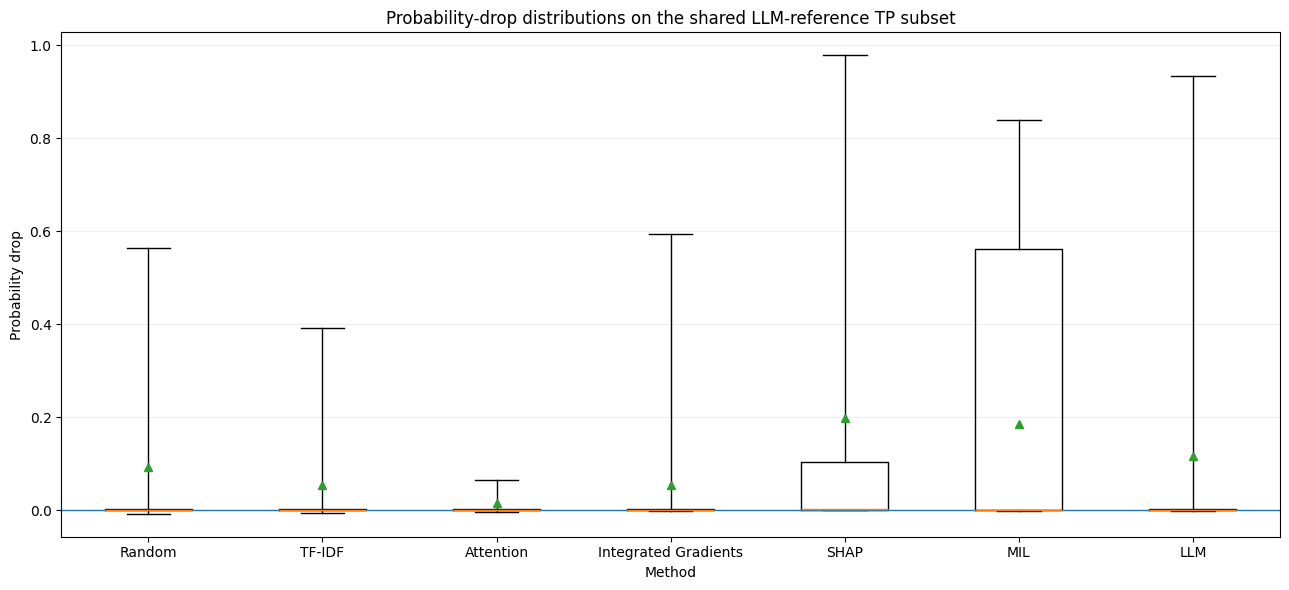

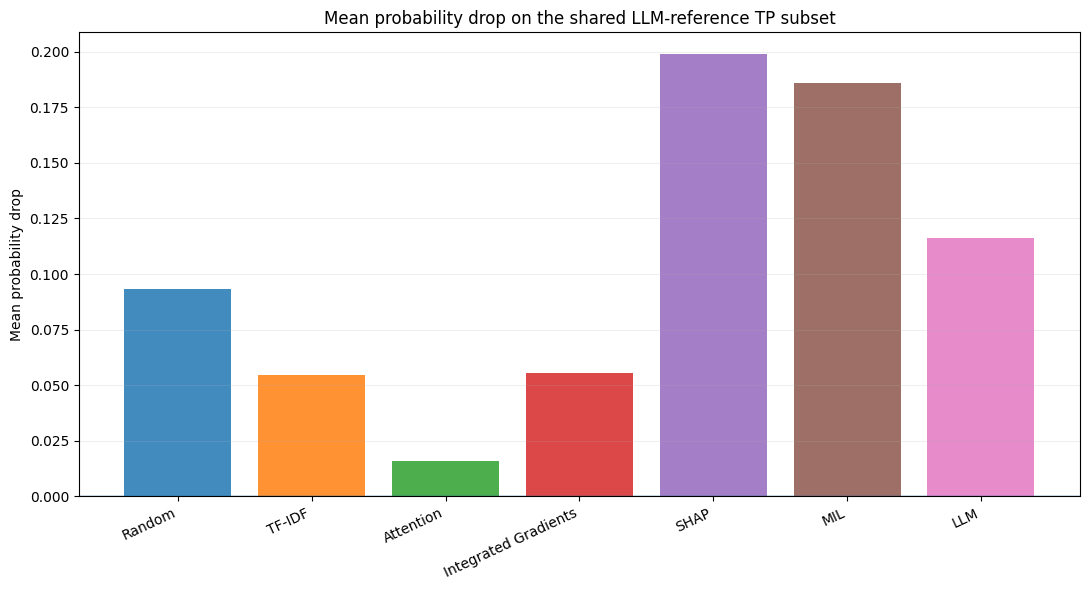

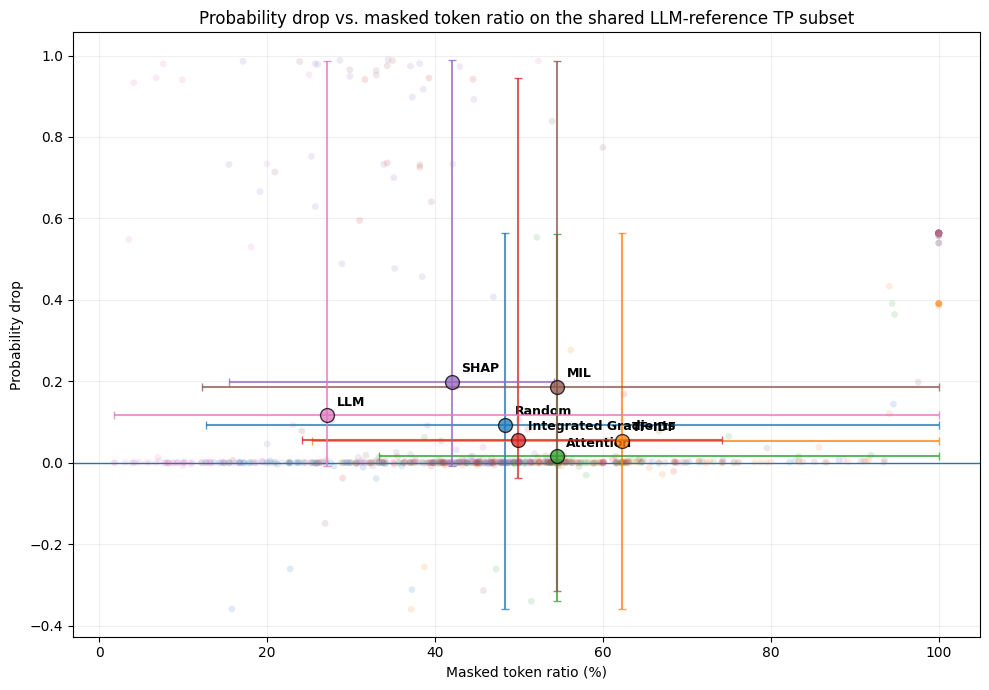

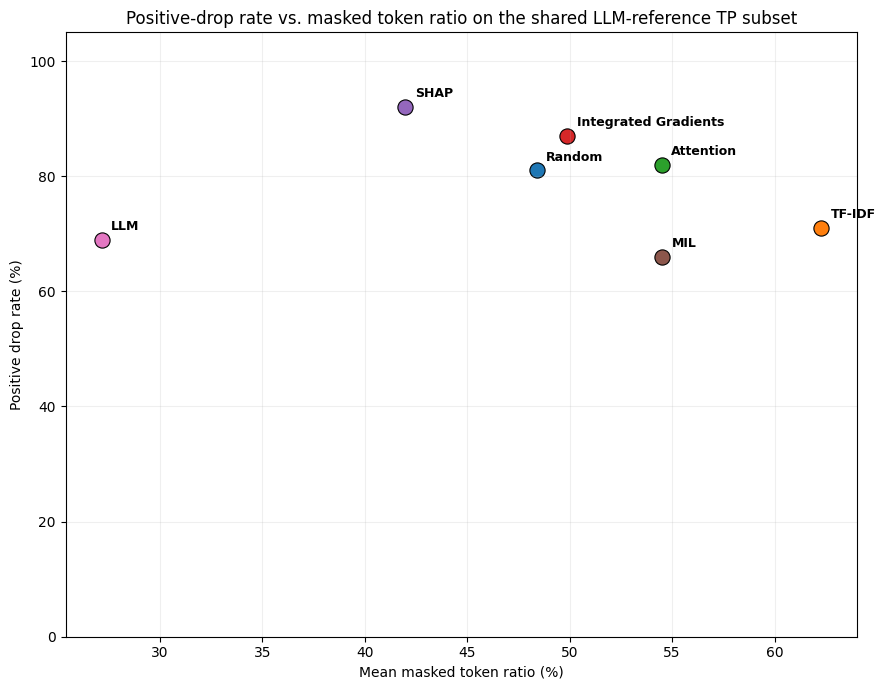

In [14]:
# Generate the perturbation plots.

plot_llm_subset_probability_drop_boxplot(
    llm_subset_arguments
)

plot_llm_subset_mean_probability_drop(
    llm_subset_summary
)

plot_llm_subset_drop_vs_masked_ratio(
    llm_subset_arguments,
    llm_subset_summary,
)

plot_llm_subset_positive_drop_rate(
    llm_subset_summary
)

# Token-level span agreement with the LLM reference

All methods are converted to sets of model-token indices. Methods that store individual indices use them directly. TF-IDF stores merged token-span start and end positions; these intervals are expanded before Precision, Recall, F1, and IoU are calculated. The end-index convention is inferred from the stored `total_masked_tokens` or `n_selected_tokens` values whenever possible.


In [15]:
# ---------------------------------------------------------------------
# Parse direct token indices and start/end token intervals robustly
# ---------------------------------------------------------------------

import ast
import json


DIRECT_TOKEN_INDEX_CANDIDATES = [
    "selected_token_indices",
    "masked_token_indices",
    "merged_span_token_indices",
    "selected_token_indices_json"
]

TOKEN_INTERVAL_CANDIDATES = [
    (
        "merged_span_token_start_indices",
        "merged_span_token_end_indices",
    ),
]

# Optional manual overrides. Leave a method at None to infer the convention
# from total_masked_tokens / n_selected_tokens.
# True  -> stored end index is inclusive:  [start, end]
# False -> stored end index is exclusive:  [start, end)
TOKEN_END_INCLUSIVE_OVERRIDES = {
    "tfidf": None,
}


def parse_int_list(value) -> list[int] | None:
    """Parse a scalar or serialized collection into a list of integers."""
    if isinstance(value, (list, tuple, set, np.ndarray, pd.Series)):
        parsed_value = value
    else:
        if value is None:
            return None

        try:
            if pd.isna(value):
                return None
        except (TypeError, ValueError):
            pass

        if isinstance(value, (int, np.integer)):
            return [int(value)]

        text = str(value).strip()

        if text.lower() in {"", "nan", "none", "null", "<na>"}:
            return None

        parsed_value = None

        for parser in (json.loads, ast.literal_eval):
            try:
                parsed_value = parser(text)
                break
            except (
                ValueError,
                SyntaxError,
                TypeError,
                json.JSONDecodeError,
            ):
                continue

        if parsed_value is None:
            # Fallback for strings such as "1, 4, 7".
            number_strings = re.findall(r"-?\d+", text)
            if not number_strings:
                return None
            parsed_value = number_strings

    if isinstance(parsed_value, dict):
        parsed_value = list(parsed_value.keys())

    if not isinstance(
        parsed_value,
        (list, tuple, set, np.ndarray, pd.Series),
    ):
        parsed_value = [parsed_value]

    result = []

    for item in parsed_value:
        try:
            result.append(int(item))
        except (TypeError, ValueError):
            continue

    return result


def expand_token_intervals(
    starts_value,
    ends_value,
    *,
    end_inclusive: bool,
) -> set[int] | None:
    """Expand paired token-span boundaries into individual token indices."""
    starts = parse_int_list(starts_value)
    ends = parse_int_list(ends_value)

    if starts is None or ends is None:
        return None

    if len(starts) != len(ends):
        return None

    token_indices = set()

    for start, end in zip(starts, ends):
        if end < start:
            continue

        stop = end + 1 if end_inclusive else end
        token_indices.update(range(start, stop))

    return token_indices


def get_expected_selected_token_count(row: pd.Series) -> int | None:
    """Get a stored token count that can identify the end convention."""
    for column in ["total_masked_tokens", "n_selected_tokens"]:
        if column not in row.index:
            continue

        value = pd.to_numeric(row[column], errors="coerce")

        if pd.notna(value):
            return int(value)

    return None


def infer_end_inclusive(
    df: pd.DataFrame,
    start_column: str,
    end_column: str,
) -> tuple[bool, dict]:
    """
    Infer whether stored interval ends are inclusive.

    The two possible expansions are compared with total_masked_tokens or
    n_selected_tokens. Exact-match counts are used first; total absolute error
    is used as a tie-breaker.
    """
    n_rows_with_count = 0
    exclusive_matches = 0
    inclusive_matches = 0
    exclusive_absolute_error = 0
    inclusive_absolute_error = 0

    for _, row in df.iterrows():
        expected_count = get_expected_selected_token_count(row)

        if expected_count is None:
            continue

        exclusive_set = expand_token_intervals(
            row[start_column],
            row[end_column],
            end_inclusive=False,
        )
        inclusive_set = expand_token_intervals(
            row[start_column],
            row[end_column],
            end_inclusive=True,
        )

        if exclusive_set is None or inclusive_set is None:
            continue

        n_rows_with_count += 1

        n_exclusive = len(exclusive_set)
        n_inclusive = len(inclusive_set)

        exclusive_matches += int(n_exclusive == expected_count)
        inclusive_matches += int(n_inclusive == expected_count)

        exclusive_absolute_error += abs(n_exclusive - expected_count)
        inclusive_absolute_error += abs(n_inclusive - expected_count)

    diagnostics = {
        "n_rows_used_for_inference": n_rows_with_count,
        "exclusive_exact_matches": exclusive_matches,
        "inclusive_exact_matches": inclusive_matches,
        "exclusive_absolute_error": exclusive_absolute_error,
        "inclusive_absolute_error": inclusive_absolute_error,
    }

    if inclusive_matches > exclusive_matches:
        return True, diagnostics

    if exclusive_matches > inclusive_matches:
        return False, diagnostics

    if inclusive_absolute_error < exclusive_absolute_error:
        return True, diagnostics

    if exclusive_absolute_error < inclusive_absolute_error:
        return False, diagnostics

    warnings.warn(
        "The interval-end convention could not be inferred uniquely. "
        "Falling back to exclusive Python-style ends [start, end). "
        "Set TOKEN_END_INCLUSIVE_OVERRIDES for the affected method "
        "if its generation code uses inclusive ends."
    )
    return False, diagnostics


def detect_token_representation(
    method: str,
    df: pd.DataFrame,
) -> dict | None:
    """Detect how one method stores its selected model-token positions."""
    for column in DIRECT_TOKEN_INDEX_CANDIDATES:
        if column in df.columns:
            return {
                "kind": "direct_indices",
                "column": column,
                "description": column,
            }

    for start_column, end_column in TOKEN_INTERVAL_CANDIDATES:
        if start_column not in df.columns or end_column not in df.columns:
            continue

        override = TOKEN_END_INCLUSIVE_OVERRIDES.get(method)

        if override is None:
            end_inclusive, diagnostics = infer_end_inclusive(
                df,
                start_column,
                end_column,
            )
            convention_source = "inferred"
        else:
            end_inclusive = bool(override)
            diagnostics = {}
            convention_source = "manual override"

        convention = "inclusive" if end_inclusive else "exclusive"

        return {
            "kind": "token_intervals",
            "start_column": start_column,
            "end_column": end_column,
            "end_inclusive": end_inclusive,
            "description": (
                f"{start_column} + {end_column} "
                f"({convention} end; {convention_source})"
            ),
            **diagnostics,
        }

    return None


def extract_token_index_set(
    row: pd.Series,
    representation: dict,
) -> set[int] | None:
    """Return one row's selected token positions as a set of integers."""
    if representation["kind"] == "direct_indices":
        parsed = parse_int_list(row[representation["column"]])
        return None if parsed is None else set(parsed)

    if representation["kind"] == "token_intervals":
        return expand_token_intervals(
            row[representation["start_column"]],
            row[representation["end_column"]],
            end_inclusive=representation["end_inclusive"],
        )

    raise ValueError(
        f"Unsupported token representation: {representation['kind']}"
    )


token_representations = {
    method: detect_token_representation(method, argument_dfs[method])
    for method in METHOD_ORDER
}

missing_token_representations = [
    method
    for method, representation in token_representations.items()
    if representation is None
]

representation_rows = []

for method in METHOD_ORDER:
    representation = token_representations[method]

    if representation is None:
        representation_rows.append({
            "method": method,
            "representation": None,
        })
        continue

    representation_rows.append({
        "method": method,
        "representation": representation["description"],
        "n_rows_used_for_inference": representation.get(
            "n_rows_used_for_inference",
            np.nan,
        ),
        "exclusive_exact_matches": representation.get(
            "exclusive_exact_matches",
            np.nan,
        ),
        "inclusive_exact_matches": representation.get(
            "inclusive_exact_matches",
            np.nan,
        ),
        "exclusive_absolute_error": representation.get(
            "exclusive_absolute_error",
            np.nan,
        ),
        "inclusive_absolute_error": representation.get(
            "inclusive_absolute_error",
            np.nan,
        ),
    })

representation_diagnostics = pd.DataFrame(representation_rows)

print("Token representations used for span agreement:")
display(representation_diagnostics)

if missing_token_representations:
    raise KeyError(
        "No supported token representation was found for: "
        f"{missing_token_representations}."
    )


Token representations used for span agreement:


,method,representation,n_rows_used_for_inference,exclusive_exact_matches,inclusive_exact_matches,exclusive_absolute_error,inclusive_absolute_error
0,random,selected_token_indices,NaN,NaN,NaN,NaN,NaN
1,tfidf,merged_span_token_start_indices + merged_span_...,438.0,0.0,438.0,2374.0,0.0
2,attention,selected_token_indices,NaN,NaN,NaN,NaN,NaN
3,ig,selected_token_indices,NaN,NaN,NaN,NaN,NaN
4,shap,selected_token_indices,NaN,NaN,NaN,NaN,NaN
5,mil,selected_token_indices_json,NaN,NaN,NaN,NaN,NaN
6,llm,selected_token_indices,NaN,NaN,NaN,NaN,NaN


In [16]:
# ---------------------------------------------------------------------
# Calculate argument-level agreement with the LLM token reference
# ---------------------------------------------------------------------


def calculate_token_overlap_metrics(
    predicted_indices: set[int] | None,
    reference_indices: set[int] | None,
) -> dict:
    """Calculate set-based overlap metrics for one argument."""
    if predicted_indices is None or reference_indices is None:
        return {
            "valid_overlap_comparison": False,
            "n_method_tokens": np.nan,
            "n_llm_tokens": np.nan,
            "n_intersection_tokens": np.nan,
            "n_union_tokens": np.nan,
            "overlap_hit": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
            "iou": np.nan,
        }

    # A valid LLM reference should contain at least one selected token.
    if len(reference_indices) == 0:
        return {
            "valid_overlap_comparison": False,
            "n_method_tokens": len(predicted_indices),
            "n_llm_tokens": 0,
            "n_intersection_tokens": np.nan,
            "n_union_tokens": np.nan,
            "overlap_hit": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
            "iou": np.nan,
        }

    intersection = predicted_indices & reference_indices
    union = predicted_indices | reference_indices

    n_predicted = len(predicted_indices)
    n_reference = len(reference_indices)
    n_intersection = len(intersection)
    n_union = len(union)

    precision = (
        n_intersection / n_predicted
        if n_predicted > 0
        else 0.0
    )

    recall = n_intersection / n_reference

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0
        else 0.0
    )

    iou = (
        n_intersection / n_union
        if n_union > 0
        else 0.0
    )

    return {
        "valid_overlap_comparison": True,
        "n_method_tokens": n_predicted,
        "n_llm_tokens": n_reference,
        "n_intersection_tokens": n_intersection,
        "n_union_tokens": n_union,
        "overlap_hit": float(n_intersection > 0),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou,
    }


# Prepare the LLM token reference once.
llm_reference_shared = prepare_test_frame(
    argument_dfs["llm"],
    method="llm",
)
llm_reference_shared = llm_reference_shared.loc[
    llm_reference_shared[ID_COLUMN].isin(shared_reference_ids)
].copy()

llm_representation = token_representations["llm"]

llm_reference_token_sets = {
    row[ID_COLUMN]: extract_token_index_set(
        row,
        llm_representation,
    )
    for _, row in llm_reference_shared.iterrows()
}

agreement_rows = []

for method in METHOD_ORDER:
    if method == "llm":
        continue

    method_test = prepare_test_frame(
        argument_dfs[method],
        method=method,
    )

    method_test = method_test.loc[
        method_test[ID_COLUMN].isin(shared_reference_ids)
    ].copy()

    method_representation = token_representations[method]

    for _, row in method_test.iterrows():
        argument_id = row[ID_COLUMN]
        method_token_set = extract_token_index_set(
            row,
            method_representation,
        )
        llm_token_set = llm_reference_token_sets.get(argument_id)

        metrics = calculate_token_overlap_metrics(
            method_token_set,
            llm_token_set,
        )

        agreement_rows.append({
            ID_COLUMN: argument_id,
            "post_id": row.get("post_id", np.nan),
            "method": method,
            "method_token_representation": method_representation[
                "description"
            ],
            "llm_token_representation": llm_representation[
                "description"
            ],
            **metrics,
        })

span_agreement_argument_level = pd.DataFrame(
    agreement_rows
)

span_agreement_argument_level["method"] = pd.Categorical(
    span_agreement_argument_level["method"],
    categories=[
        method
        for method in METHOD_ORDER
        if method != "llm"
    ],
    ordered=True,
)

span_agreement_argument_level = (
    span_agreement_argument_level
    .sort_values(["method", ID_COLUMN])
    .reset_index(drop=True)
)

span_agreement_argument_level.to_csv(
    LLM_TABLE_DIR / "methods_vs_llm_token_overlap_argument_level.csv",
    index=False,
)

agreement_validity = (
    span_agreement_argument_level
    .groupby("method", observed=True)
    .agg(
        n_arguments=(ID_COLUMN, "nunique"),
        n_valid_comparisons=(
            "valid_overlap_comparison",
            "sum",
        ),
        n_missing_comparisons=(
            "valid_overlap_comparison",
            lambda values: (~values.astype(bool)).sum(),
        ),
    )
)

display(agreement_validity)


,n_arguments,n_valid_comparisons,n_missing_comparisons
method,,,
random,100,100,0
tfidf,100,100,0
attention,100,100,0
ig,100,100,0
shap,100,100,0
mil,100,100,0


In [17]:
# ---------------------------------------------------------------------
# Aggregate macro and micro token-overlap metrics
# ---------------------------------------------------------------------

def summarize_span_agreement_group(
    method_df: pd.DataFrame,
) -> dict:
    """Summarize one method's agreement with the LLM reference."""
    valid = method_df.loc[
        method_df["valid_overlap_comparison"].eq(True)
    ].copy()

    intersection_sum = valid["n_intersection_tokens"].sum()
    method_token_sum = valid["n_method_tokens"].sum()
    llm_token_sum = valid["n_llm_tokens"].sum()
    union_sum = valid["n_union_tokens"].sum()

    micro_precision = (
        intersection_sum / method_token_sum
        if method_token_sum > 0
        else 0.0
    )

    micro_recall = (
        intersection_sum / llm_token_sum
        if llm_token_sum > 0
        else np.nan
    )

    micro_f1 = (
        2 * micro_precision * micro_recall
        / (micro_precision + micro_recall)
        if pd.notna(micro_recall)
        and micro_precision + micro_recall > 0
        else 0.0
    )

    micro_iou = (
        intersection_sum / union_sum
        if union_sum > 0
        else 0.0
    )

    return {
        "n_arguments": method_df[ID_COLUMN].nunique(),
        "n_valid_comparisons": len(valid),
        "overlap_hit_rate": valid["overlap_hit"].mean(),
        "macro_precision": valid["precision"].mean(),
        "macro_recall": valid["recall"].mean(),
        "macro_f1": valid["f1"].mean(),
        "median_f1": valid["f1"].median(),
        "macro_iou": valid["iou"].mean(),
        "median_iou": valid["iou"].median(),
        "micro_precision": micro_precision,
        "micro_recall": micro_recall,
        "micro_f1": micro_f1,
        "micro_iou": micro_iou,
        "mean_method_selected_tokens": valid["n_method_tokens"].mean(),
        "mean_llm_reference_tokens": valid["n_llm_tokens"].mean(),
    }


agreement_summary_rows = []

for method in [
    method
    for method in METHOD_ORDER
    if method != "llm"
]:
    method_df = span_agreement_argument_level.loc[
        span_agreement_argument_level["method"].eq(method)
    ]

    agreement_summary_rows.append({
        "method": method,
        **summarize_span_agreement_group(method_df),
    })

span_agreement_summary = pd.DataFrame(
    agreement_summary_rows
)

span_agreement_summary["method"] = pd.Categorical(
    span_agreement_summary["method"],
    categories=[
        method
        for method in METHOD_ORDER
        if method != "llm"
    ],
    ordered=True,
)

span_agreement_summary = (
    span_agreement_summary
    .sort_values("method")
    .reset_index(drop=True)
)

span_agreement_summary.to_csv(
    LLM_TABLE_DIR / "methods_vs_llm_token_overlap_summary.csv",
    index=False,
)

display(
    span_agreement_summary.style.format({
        "overlap_hit_rate": "{:.2%}",
        "macro_precision": "{:.4f}",
        "macro_recall": "{:.4f}",
        "macro_f1": "{:.4f}",
        "median_f1": "{:.4f}",
        "macro_iou": "{:.4f}",
        "median_iou": "{:.4f}",
        "micro_precision": "{:.4f}",
        "micro_recall": "{:.4f}",
        "micro_f1": "{:.4f}",
        "micro_iou": "{:.4f}",
        "mean_method_selected_tokens": "{:.2f}",
        "mean_llm_reference_tokens": "{:.2f}",
    })
)

,method,n_arguments,n_valid_comparisons,overlap_hit_rate,macro_precision,macro_recall,macro_f1,median_f1,macro_iou,median_iou,micro_precision,micro_recall,micro_f1,micro_iou,mean_method_selected_tokens,mean_llm_reference_tokens
0,random,100,100,96.00%,0.2577,0.4664,0.2950,0.2168,0.2056,0.1216,0.2337,0.3975,0.2943,0.1726,29.06,17.08
1,tfidf,100,100,90.00%,0.2573,0.4944,0.2993,0.2376,0.2089,0.1348,0.2029,0.4666,0.2828,0.1647,39.29,17.08
2,attention,100,100,96.00%,0.2522,0.4334,0.2639,0.2470,0.1619,0.1409,0.1895,0.4063,0.2585,0.1484,36.62,17.08
3,ig,100,100,96.00%,0.2817,0.4995,0.3081,0.3088,0.1976,0.1826,0.2218,0.4842,0.3043,0.1794,37.28,17.08
4,shap,100,100,98.00%,0.3007,0.5568,0.3306,0.3077,0.2111,0.1818,0.2436,0.5234,0.3325,0.1994,36.70,17.08
5,mil,100,100,90.00%,0.3189,0.6608,0.3808,0.3299,0.2769,0.1976,0.2808,0.5890,0.3803,0.2348,35.83,17.08


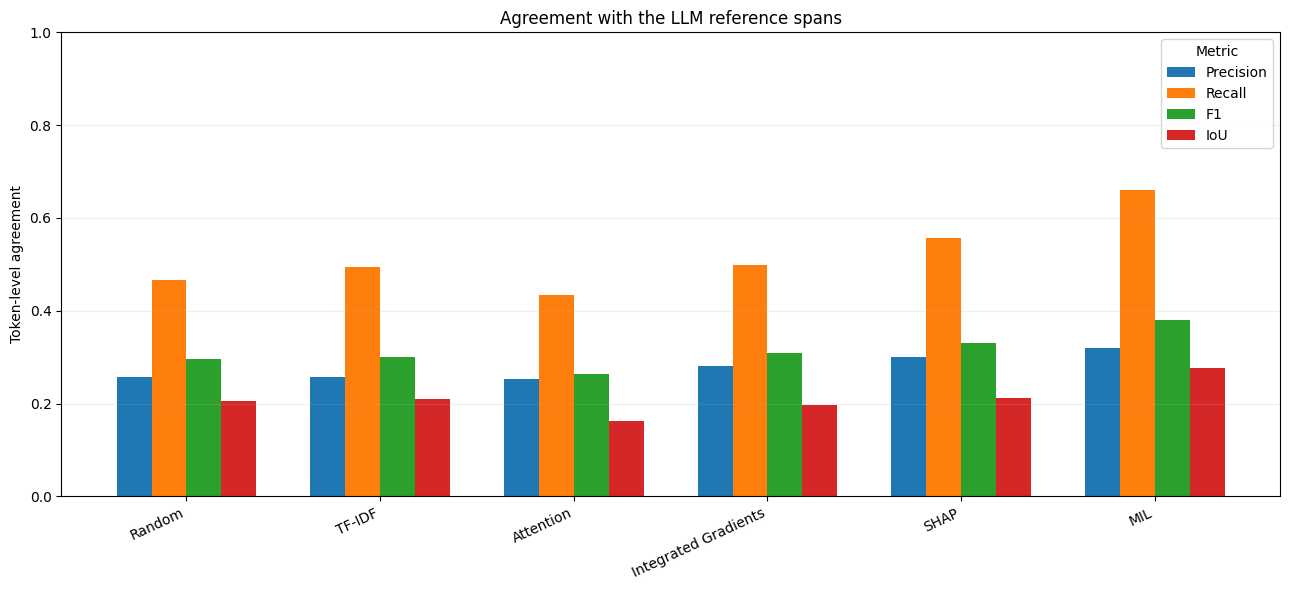

/var/folders/9c/mdcbw50d74b4v7yjj79xw8yh0000gn/T/ipykernel_71109/3368388685.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


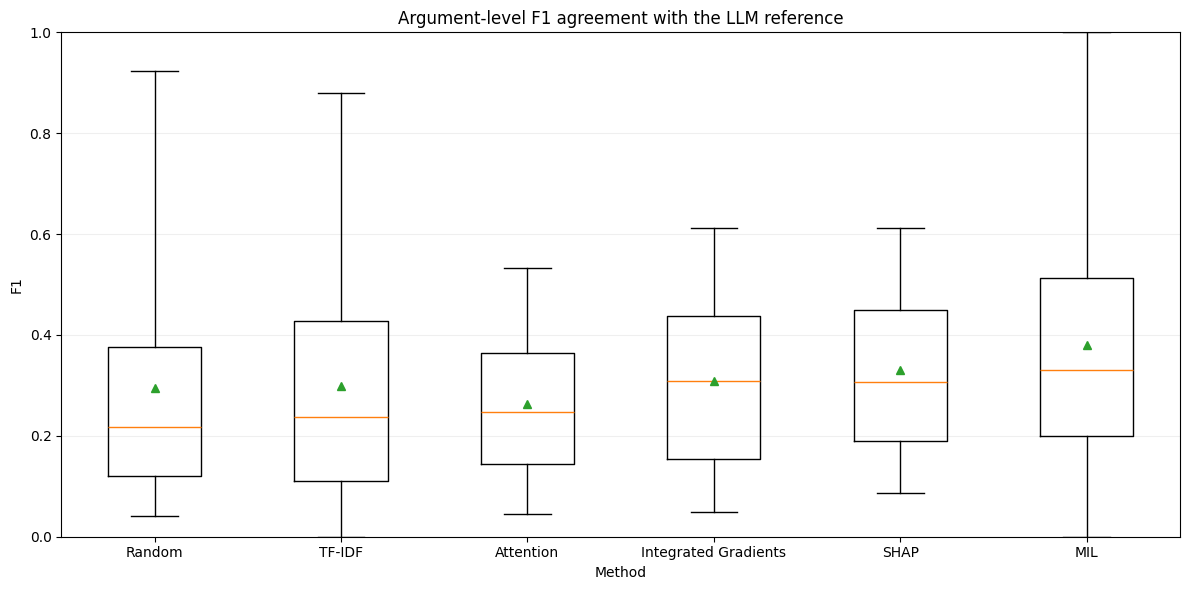

/var/folders/9c/mdcbw50d74b4v7yjj79xw8yh0000gn/T/ipykernel_71109/3368388685.py:98: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


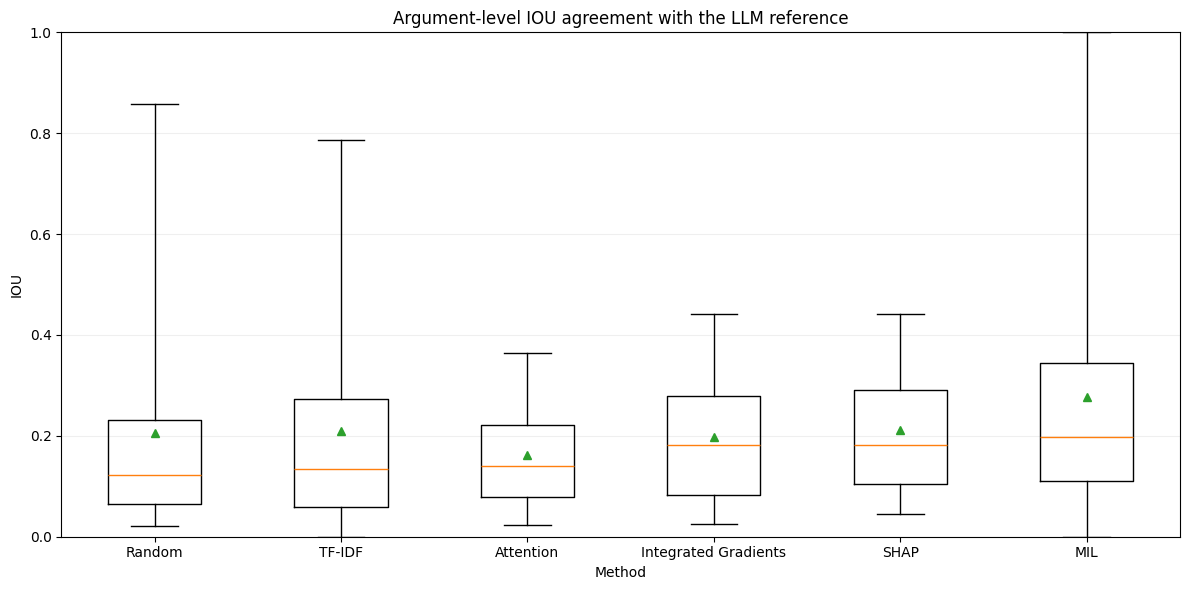

In [18]:
# ---------------------------------------------------------------------
# Plot token-level agreement with the LLM reference
# ---------------------------------------------------------------------

def plot_llm_agreement_metric_bars(
    summary_df: pd.DataFrame,
) -> None:
    """Plot macro precision, recall, F1, and IoU side by side."""
    metric_columns = [
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "macro_iou",
    ]

    metric_labels = [
        "Precision",
        "Recall",
        "F1",
        "IoU",
    ]

    methods = summary_df["method"].astype(str).tolist()
    x_positions = np.arange(len(methods))
    width = 0.18

    fig, ax = plt.subplots(figsize=(13, 6))

    for metric_index, (column, label) in enumerate(
        zip(metric_columns, metric_labels)
    ):
        offset = (
            metric_index - (len(metric_columns) - 1) / 2
        ) * width

        ax.bar(
            x_positions + offset,
            summary_df[column],
            width=width,
            label=label,
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        [method_label(method) for method in methods],
        rotation=25,
        ha="right",
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("Token-level agreement")
    ax.set_title("Agreement with the LLM reference spans")
    ax.legend(title="Metric")
    ax.grid(axis="y", alpha=0.20)

    fig.tight_layout()
    save_llm_figure(
        fig,
        "token_overlap_macro_metrics_vs_llm",
    )
    plt.show()


def plot_llm_agreement_distribution(
    argument_df: pd.DataFrame,
    metric: str,
) -> None:
    """Plot an argument-level F1 or IoU distribution."""
    if metric not in {"f1", "iou"}:
        raise ValueError("metric must be either 'f1' or 'iou'.")

    method_order_without_llm = [
        method
        for method in METHOD_ORDER
        if method != "llm"
    ]

    values = []
    labels = []

    for method in method_order_without_llm:
        current_values = (
            argument_df.loc[
                argument_df["method"].eq(method),
                metric,
            ]
            .dropna()
            .to_numpy()
        )

        if len(current_values) == 0:
            continue

        values.append(current_values)
        labels.append(method_label(method))

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.boxplot(
        values,
        labels=labels,
        showmeans=True,
        showfliers=False,
        whis=(5, 95),
    )

    ax.set_ylim(0, 1)
    ax.set_xlabel("Method")
    ax.set_ylabel(metric.upper())
    ax.set_title(
        f"Argument-level {metric.upper()} agreement with the LLM reference"
    )
    ax.grid(axis="y", alpha=0.20)

    fig.tight_layout()
    save_llm_figure(
        fig,
        f"token_overlap_{metric}_distribution_vs_llm",
    )
    plt.show()


plot_llm_agreement_metric_bars(
    span_agreement_summary
)

plot_llm_agreement_distribution(
    span_agreement_argument_level,
    metric="f1",
)

plot_llm_agreement_distribution(
    span_agreement_argument_level,
    metric="iou",
)

# Paired comparison against the random span baseline

Since all methods are evaluated on the same reference arguments, agreement scores can also be compared argument by argument. The following table reports paired differences relative to the random baseline and a two-sided Wilcoxon signed-rank test. The p-values are Holm-adjusted separately for F1 and IoU.

In [19]:
# ---------------------------------------------------------------------
# Paired significance tests against the random span baseline
# ---------------------------------------------------------------------

def holm_adjust(
    p_values: pd.Series,
) -> pd.Series:
    """Holm-adjust a Series of p-values while preserving its index."""
    p_values = p_values.astype(float)
    n_tests = len(p_values)

    if n_tests == 0:
        return p_values

    order = np.argsort(p_values.to_numpy())
    sorted_p = p_values.to_numpy()[order]

    adjusted_sorted = np.empty(n_tests, dtype=float)
    running_max = 0.0

    for rank, p_value in enumerate(sorted_p):
        adjusted = (n_tests - rank) * p_value
        running_max = max(running_max, adjusted)
        adjusted_sorted[rank] = min(running_max, 1.0)

    adjusted = np.empty(n_tests, dtype=float)
    adjusted[order] = adjusted_sorted

    return pd.Series(
        adjusted,
        index=p_values.index,
    )


RANDOM_METHOD = "random"
paired_test_rows = []

for metric in ["f1", "iou"]:
    metric_wide = (
        span_agreement_argument_level
        .pivot(
            index=ID_COLUMN,
            columns="method",
            values=metric,
        )
    )

    if RANDOM_METHOD not in metric_wide.columns:
        warnings.warn(
            "Random baseline is unavailable; paired tests are skipped."
        )
        break

    for method in metric_wide.columns:
        method = str(method)

        if method == RANDOM_METHOD:
            continue

        paired = metric_wide[[RANDOM_METHOD, method]].dropna()
        differences = paired[method] - paired[RANDOM_METHOD]

        if len(paired) == 0:
            statistic = np.nan
            p_value = np.nan
        elif np.allclose(differences, 0):
            statistic = 0.0
            p_value = 1.0
        else:
            test_result = wilcoxon(
                paired[method],
                paired[RANDOM_METHOD],
                alternative="two-sided",
                zero_method="wilcox",
            )
            statistic = test_result.statistic
            p_value = test_result.pvalue

        paired_test_rows.append({
            "metric": metric,
            "method": method,
            "reference_method": RANDOM_METHOD,
            "n_paired_arguments": len(paired),
            "mean_method_score": paired[method].mean(),
            "mean_random_score": paired[RANDOM_METHOD].mean(),
            "mean_difference_vs_random": differences.mean(),
            "median_difference_vs_random": differences.median(),
            "win_rate_vs_random": (differences > 0).mean(),
            "wilcoxon_statistic": statistic,
            "p_value": p_value,
        })

paired_agreement_tests = pd.DataFrame(
    paired_test_rows
)

if not paired_agreement_tests.empty:
    paired_agreement_tests["p_value_holm"] = (
        paired_agreement_tests
        .groupby("metric", group_keys=False)["p_value"]
        .apply(holm_adjust)
    )

    paired_agreement_tests["significant_holm_0_05"] = (
        paired_agreement_tests["p_value_holm"] < 0.05
    )

    paired_agreement_tests.to_csv(
        LLM_TABLE_DIR / "methods_vs_random_llm_agreement_paired_tests.csv",
        index=False,
    )

    display(
        paired_agreement_tests.style.format({
            "mean_method_score": "{:.4f}",
            "mean_random_score": "{:.4f}",
            "mean_difference_vs_random": "{:+.4f}",
            "median_difference_vs_random": "{:+.4f}",
            "win_rate_vs_random": "{:.2%}",
            "wilcoxon_statistic": "{:.2f}",
            "p_value": "{:.4g}",
            "p_value_holm": "{:.4g}",
        })
    )

,metric,method,reference_method,n_paired_arguments,mean_method_score,mean_random_score,mean_difference_vs_random,median_difference_vs_random,win_rate_vs_random,wilcoxon_statistic,p_value,p_value_holm,significant_holm_0_05
0,f1,tfidf,random,100,0.2993,0.2950,+0.0043,-0.0128,41.00%,2294.50,0.768,0.8342,False
1,f1,attention,random,100,0.2639,0.2950,-0.0311,-0.0028,49.00%,2242.50,0.4171,0.8342,False
2,f1,ig,random,100,0.3081,0.2950,+0.0131,+0.0311,59.00%,2105.00,0.1966,0.5897,False
3,f1,shap,random,100,0.3306,0.2950,+0.0356,+0.0669,60.00%,1819.00,0.04485,0.1794,False
4,f1,mil,random,100,0.3808,0.2950,+0.0858,+0.0701,67.00%,808.00,2.186e-07,1.093e-06,True
5,iou,tfidf,random,100,0.2089,0.2056,+0.0033,-0.0104,41.00%,2334.50,0.8799,0.8799,False
6,iou,attention,random,100,0.1619,0.2056,-0.0437,-0.0015,49.00%,2224.00,0.381,0.8565,False
7,iou,ig,random,100,0.1976,0.2056,-0.0080,+0.0206,59.00%,2169.00,0.2855,0.8565,False
8,iou,shap,random,100,0.2111,0.2056,+0.0056,+0.0440,60.00%,1919.00,0.09972,0.3989,False
9,iou,mil,random,100,0.2769,0.2056,+0.0713,+0.0622,67.00%,734.00,4.477e-08,2.238e-07,True
